In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel("Dataset/Delivery_prediction_Dataset_.xlsx",index_col='delivery_id')

In [12]:
df.head()

,delivery_partner,order_date,delivery_date,state,city,package_type,vehicle_type,delivery_mode,weather_condition,traffic_level,...,address_verified,payment_method,fuel_level,vehicle_breakdown,delivery_attempts,holiday,delivery_cost_ngn,failure_reason,delivery_status,delivery_failure
delivery_id,,,,,,,,,,,,,,,,,,,,,
DLV000001,Jumia Logistics,2025-01-01,2025-01-02,Oyo,Ibadan,Electronics,Bike,Standard,Sunny,Heavy,...,No,Cash on Delivery,High,Yes,3,Yes,39321,Flood,Failed,1
DLV000002,Jumia Logistics,2025-01-01,2025-01-02,FCT,Garki,Food,Bike,Standard,Sunny,Low,...,Yes,Transfer,Medium,No,3,No,25196,NaN,Delivered,0
DLV000003,Jumia Logistics,2025-01-01,2025-01-02,Kano,Kano,Food,Bike,Standard,Harmattan,Moderate,...,Yes,Transfer,Medium,No,3,No,40452,NaN,Delivered,0
DLV000004,Kobo360,2025-01-01,2025-01-02,Oyo,Ibadan,Food,Bike,Standard,Heavy Rain,Low,...,No,Transfer,Medium,No,3,Yes,12402,Customer Not Home,Failed,1
DLV000005,Jumia Logistics,2025-01-01,2025-01-02,Kano,Kano,Documents,Bike,Standard,Harmattan,Moderate,...,Yes,Transfer,High,Yes,1,No,9724,NaN,Delivered,0


In [13]:
def eda_summary(df):
    summary=pd.DataFrame({'dtype':df.dtypes
        ,'non_null':df.count()
        ,'null_count':df.isnull().sum()
        ,'null_pct':(df.isnull().mean()*100).round(2)
        ,'unique':df.nunique()
        ,'unique_pct':(df.nunique()/len(df)*100).round(2)})
    num_stats=df.describe().T[['mean','std','min','max']]
    summary=summary.join(num_stats)
    return summary

In [14]:
eda_summary(df)

,dtype,non_null,null_count,null_pct,unique,unique_pct,mean,std,min,max
delivery_partner,str,10000,0,0.00,4,0.04,NaN,NaN,NaN,NaN
order_date,str,10000,0,0.00,1,0.01,NaN,NaN,NaN,NaN
delivery_date,str,10000,0,0.00,1,0.01,NaN,NaN,NaN,NaN
state,str,10000,0,0.00,6,0.06,NaN,NaN,NaN,NaN
city,str,10000,0,0.00,10,0.10,NaN,NaN,NaN,NaN
package_type,str,10000,0,0.00,3,0.03,NaN,NaN,NaN,NaN
vehicle_type,str,10000,0,0.00,3,0.03,NaN,NaN,NaN,NaN
delivery_mode,str,10000,0,0.00,1,0.01,NaN,NaN,NaN,NaN
weather_condition,str,10000,0,0.00,4,0.04,NaN,NaN,NaN,NaN
traffic_level,str,10000,0,0.00,4,0.04,NaN,NaN,NaN,NaN


In [17]:
def analyze_distributions(df, columns, n_cols=2, bins=30, figsize=(14, 4)):
    # 1. Summary stats table
    stats_summary = pd.DataFrame(index=columns, columns=['Count', 'Mean', 'Median', 'Skew', 'Kurtosis', '%_NaN'])

    for i, col in enumerate(columns):
        if col not in df.columns:
            print(f" Column {col} not found, skipping.")
            continue

        if not np.issubdtype(df[col].dtype, np.number):
            print(f" Column {col} is not numeric, skipping.")
            continue

        # 2. Calculate stats
        stats_summary.loc[col, 'Count'] = df[col].count()
        stats_summary.loc[col, 'Mean'] = df[col].mean()
        stats_summary.loc[col, 'Median'] = df[col].median()
        stats_summary.loc[col, 'Skew'] = df[col].skew()
        stats_summary.loc[col, 'Kurtosis'] = df[col].kurtosis()
        stats_summary.loc[col, '%_NaN'] = df[col].isna().mean() * 100

        # 3. Plots: 1 row = 1 column
        fig, axes = plt.subplots(1, 2, figsize=(figsize[0], figsize[1]))
        fig.suptitle(f"Distribution of '{col}'", fontsize=16, y=1.02)

        # Axis 0: Histogram + KDE = Shape
        sns.histplot(df[col].dropna(), kde=True, bins=bins, ax=axes[0])
        axes[0].axvline(df[col].mean(), color='r', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
        axes[0].axvline(df[col].median(), color='g', linestyle='-', label=f'Median: {df[col].median():.2f}')
        axes[0].legend()
        axes[0].set_title('Histogram + KDE')

        # Axis 1: Boxplot = Outliers + Skewness
        sns.boxplot(x=df[col].dropna(), ax=axes[1])
        axes[1].set_title('Boxplot')

        plt.tight_layout()
        plt.show()

    # 4. Display final table
    print("\n=== Summary Table ===")
    display(stats_summary.round(2))

    # 5. Auto recommendations
    print("\n=== Some remarks ===")
    for col in columns:
        skew = stats_summary.loc[col, 'Skew']
        if pd.isna(skew):
            continue
        if abs(skew) > 1:
            print(f"-> {col}: Skew={skew:.2f} | Highly skewed")
        elif abs(skew) > 0.5:
            print(f"-> {col}: Skew={skew:.2f} | Moderately skewed.")
        else:
            print(f"-> {col}: Skew={skew:.2f} | Fairly symmetric. Normal distribution .")

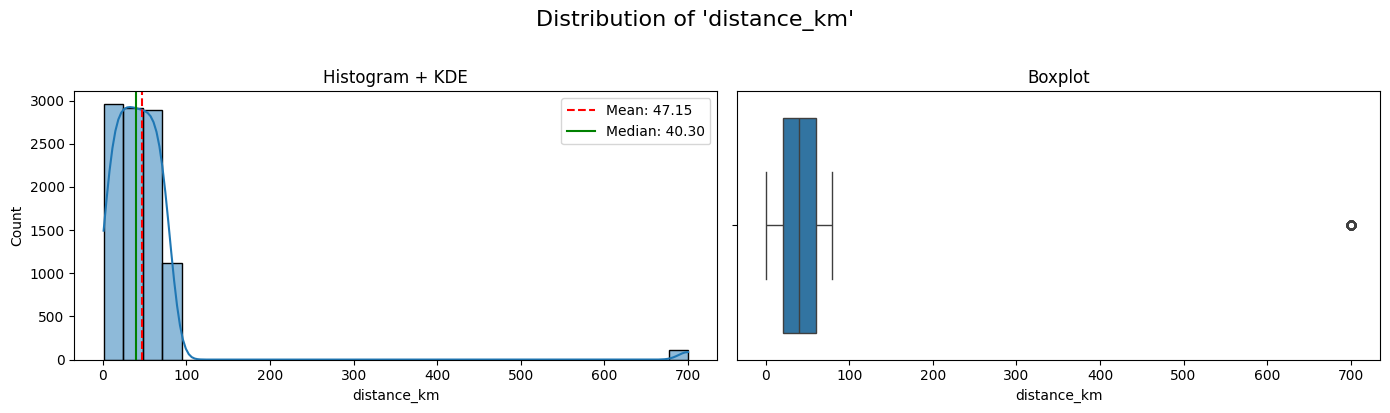

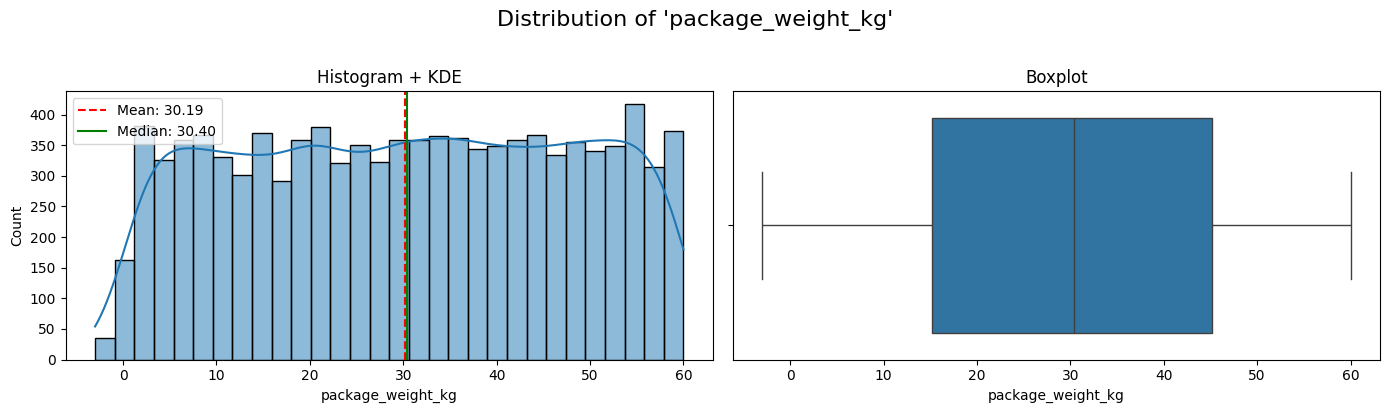

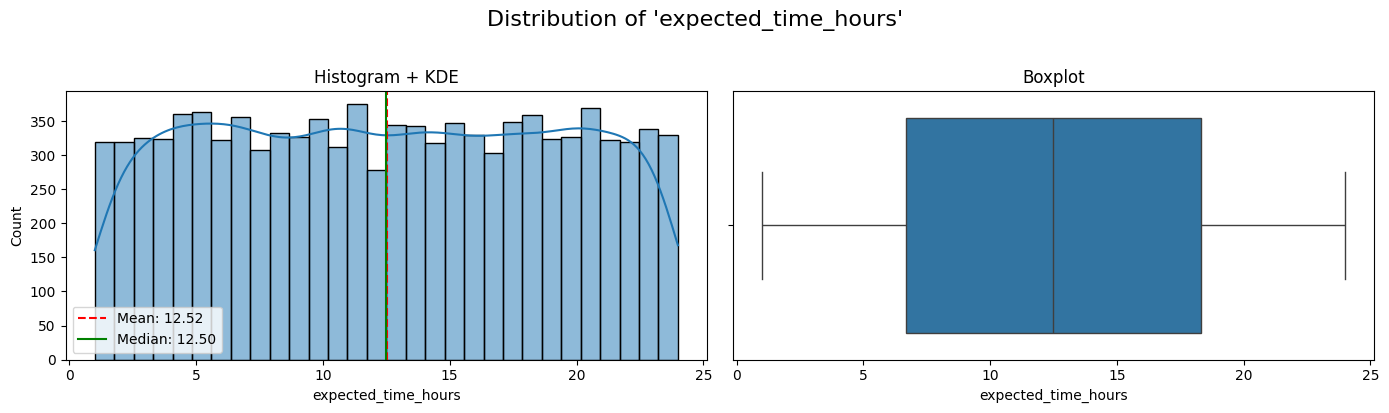

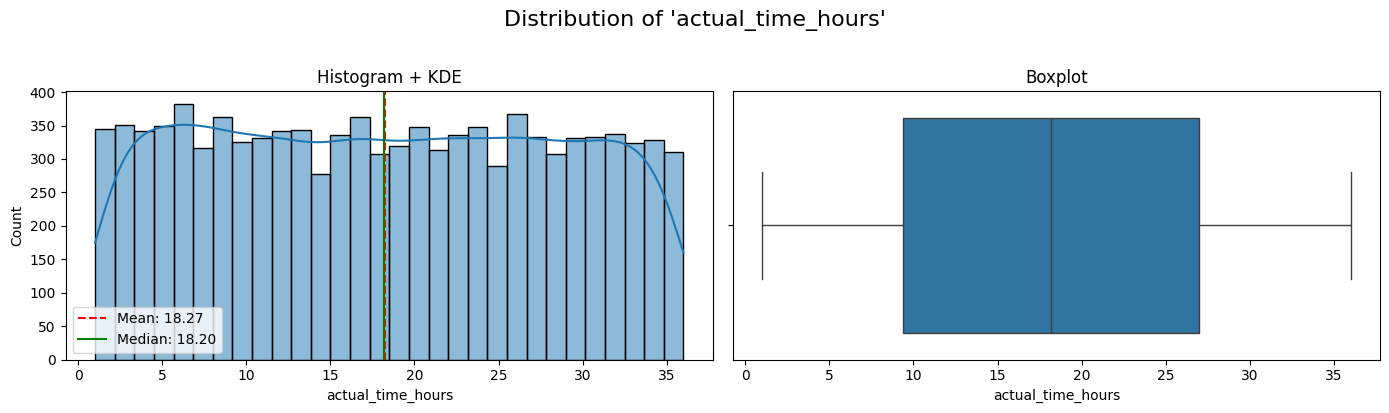

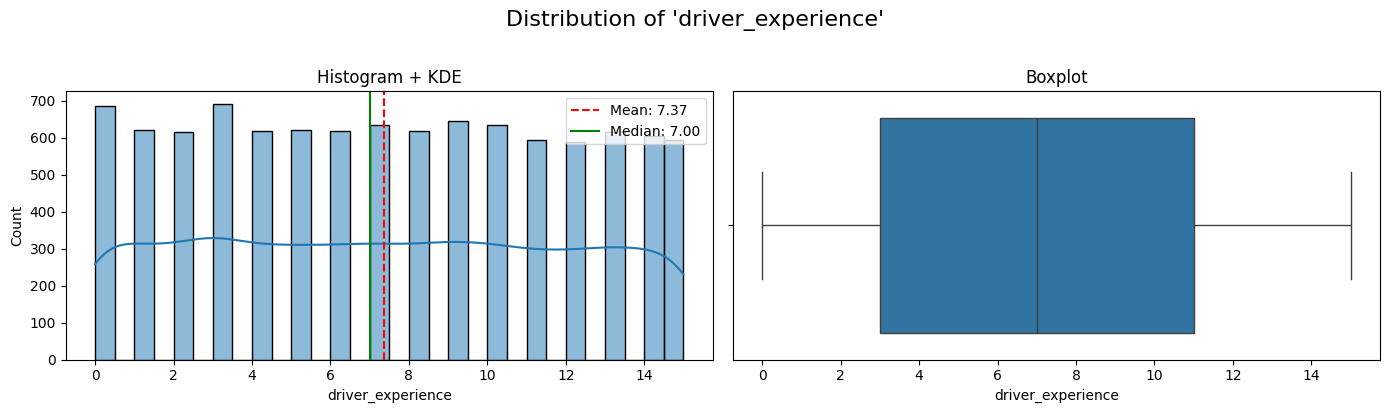

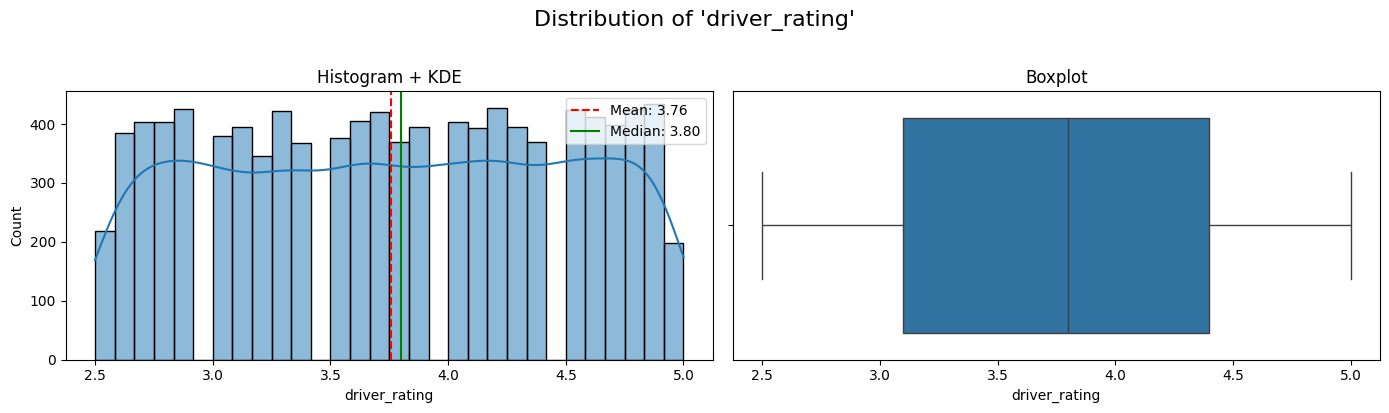

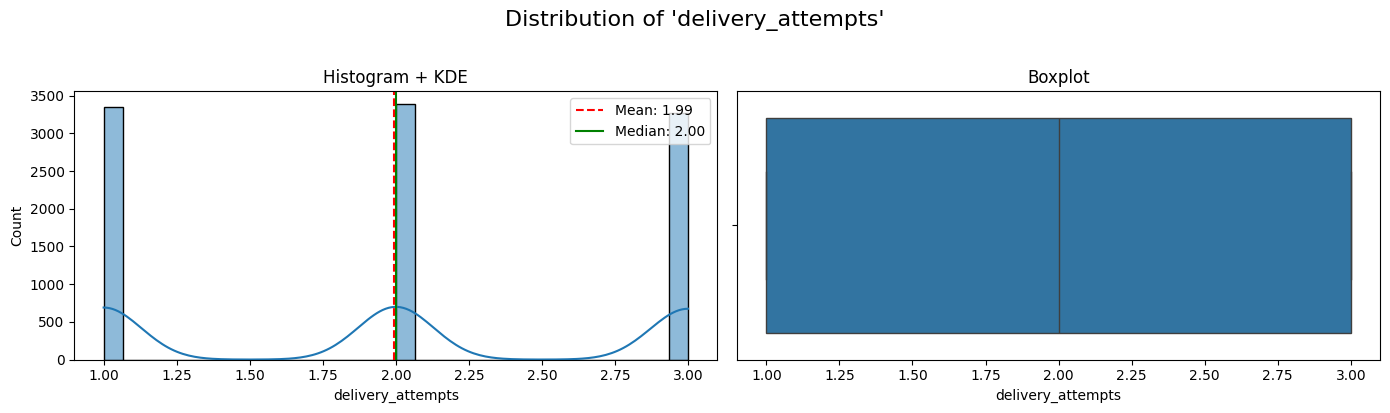

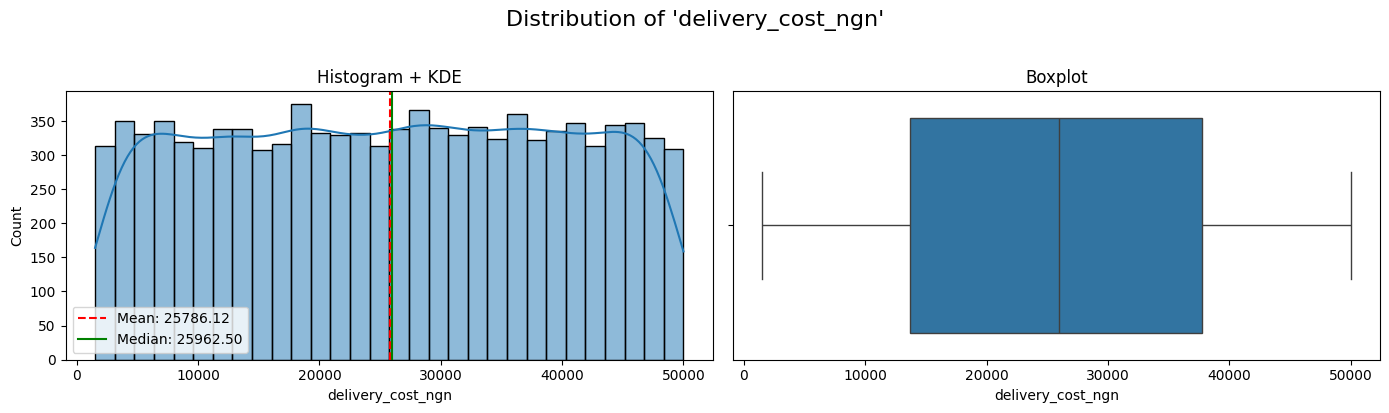


=== Summary Table ===


,Count,Mean,Median,Skew,Kurtosis,%_NaN
distance_km,10000,47.14763,40.3,8.112931,71.624231,0.0
package_weight_kg,10000,30.19447,30.4,-0.025729,-1.19236,0.0
expected_time_hours,10000,12.51671,12.5,0.004852,-1.203834,0.0
actual_time_hours,10000,18.26741,18.2,0.022645,-1.213373,0.0
driver_experience,10000,7.3701,7.0,0.028915,-1.204131,0.0
driver_rating,10000,3.75939,3.8,-0.020937,-1.207055,0.0
delivery_attempts,10000,1.9922,2.0,0.014272,-1.487468,0.0
delivery_cost_ngn,10000,25786.1244,25962.5,-0.01045,-1.194347,0.0



=== Some remarks ===
-> distance_km: Skew=8.11 | Highly skewed
-> package_weight_kg: Skew=-0.03 | Fairly symmetric. Normal distribution .
-> expected_time_hours: Skew=0.00 | Fairly symmetric. Normal distribution .
-> actual_time_hours: Skew=0.02 | Fairly symmetric. Normal distribution .
-> driver_experience: Skew=0.03 | Fairly symmetric. Normal distribution .
-> driver_rating: Skew=-0.02 | Fairly symmetric. Normal distribution .
-> delivery_attempts: Skew=0.01 | Fairly symmetric. Normal distribution .
-> delivery_cost_ngn: Skew=-0.01 | Fairly symmetric. Normal distribution .


In [18]:
numeric_cols = [
    'distance_km', 
    'package_weight_kg', 
    'expected_time_hours', 
    'actual_time_hours', 
    'driver_experience', 
    'driver_rating', 
    'delivery_attempts', 
    'delivery_cost_ngn'
]
analyze_distributions(df, numeric_cols)


 ANALYSIS: delivery_partner | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 4

Top categories:


,Count,%
delivery_partner,,
GIG Logistics,2580,25.80
Kobo360,2514,25.14
Jumia Logistics,2484,24.84
Kwik,2422,24.22



 No category < 1.0%


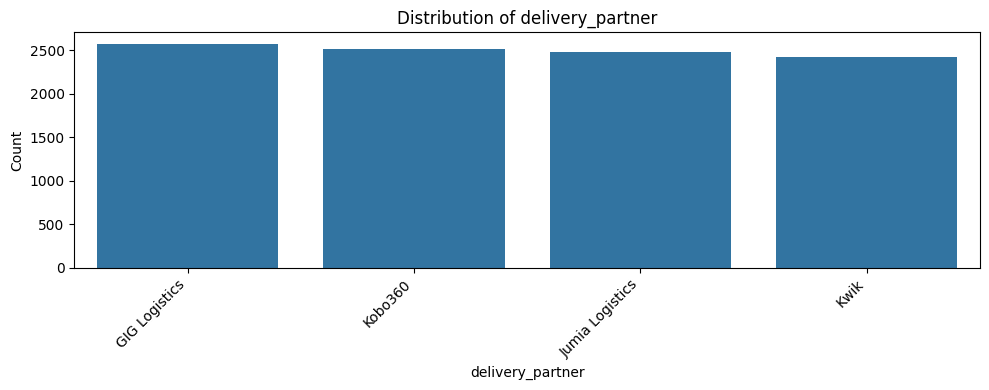


 ANALYSIS: order_date | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 1

Top categories:


,Count,%
order_date,,
2025-01-01,10000,100.0



 No category < 1.0%
 STRONG IMBALANCE: '2025-01-01' = 100.0%


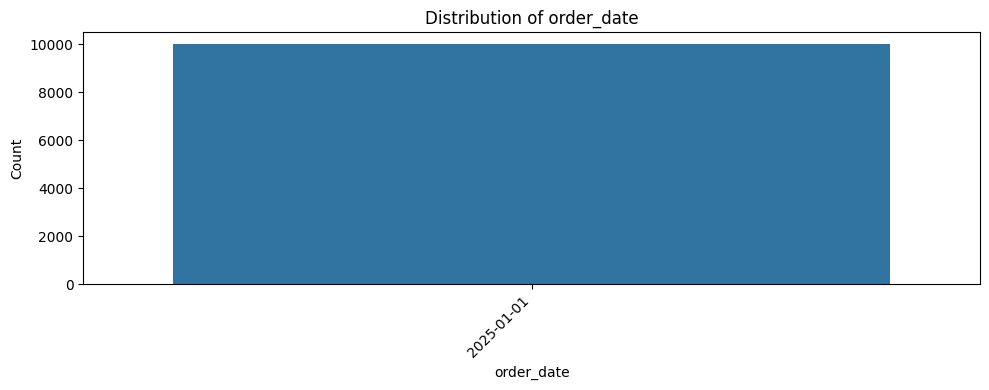


 ANALYSIS: delivery_date | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 1

Top categories:


,Count,%
delivery_date,,
2025-01-02,10000,100.0



 No category < 1.0%
 STRONG IMBALANCE: '2025-01-02' = 100.0%


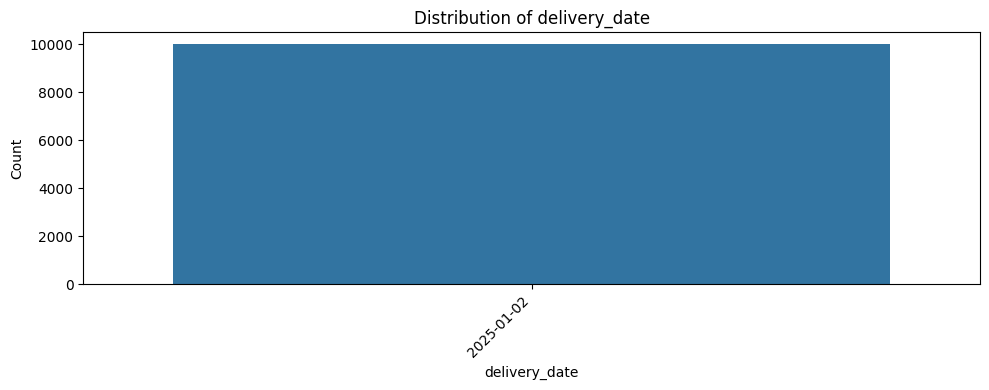


 ANALYSIS: state | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 6

Top categories:


,Count,%
state,,
Kano,1774,17.74
Rivers,1690,16.90
Enugu,1658,16.58
FCT,1653,16.53
Lagos,1643,16.43
Oyo,1582,15.82



 No category < 1.0%


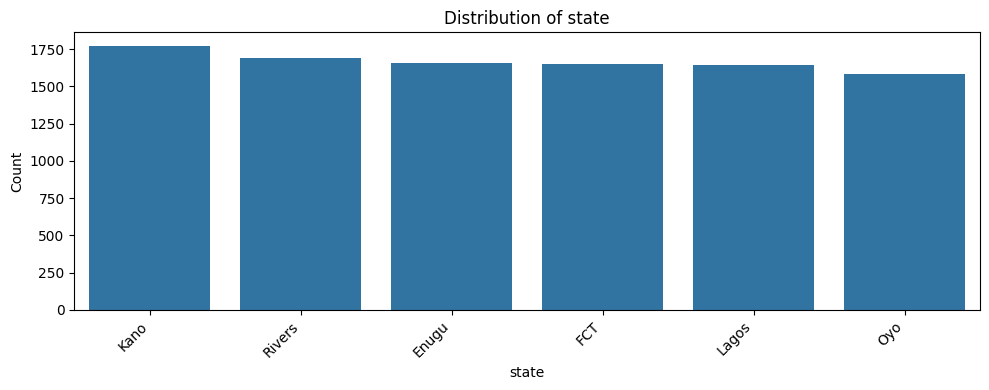


 ANALYSIS: city | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 10

Top categories:


,Count,%
city,,
Kano,1760,17.60
Port Harcourt,1673,16.73
Enugu,1640,16.40
Ibadan,1569,15.69
Garki,843,8.43
Wuse,796,7.96
Ikeja,569,5.69
Yaba,548,5.48
Lekki,514,5.14



 1 categor(y/ies) < 1.0% -> Risk of overfitting. Consider grouping into 'Other'.
['Lekkii']


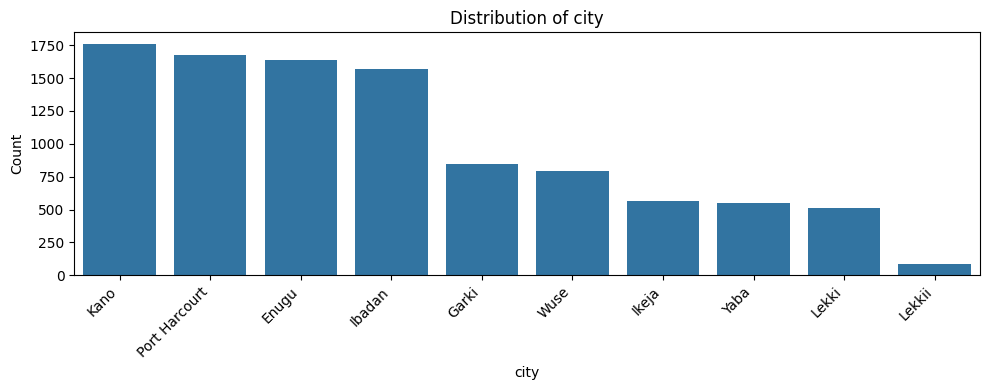


 ANALYSIS: package_type | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 3

Top categories:


,Count,%
package_type,,
Food,3430,34.30
Documents,3362,33.62
Electronics,3208,32.08



 No category < 1.0%


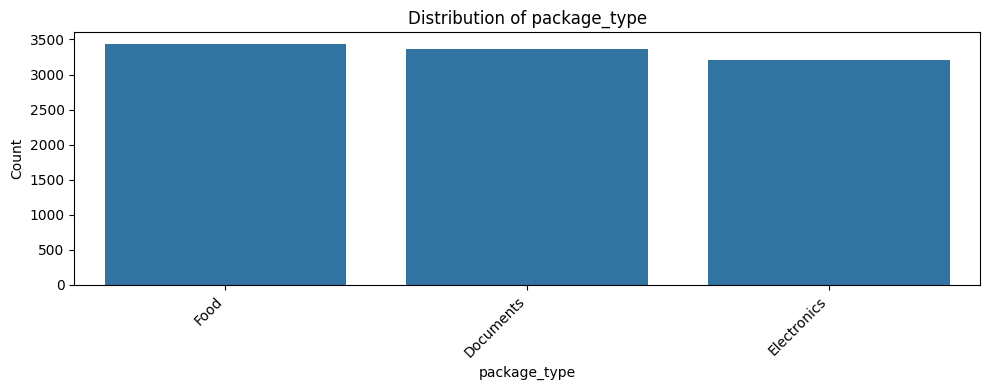


 ANALYSIS: vehicle_type | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 3

Top categories:


,Count,%
vehicle_type,,
Truck,3343,33.43
Van,3332,33.32
Bike,3325,33.25



 No category < 1.0%


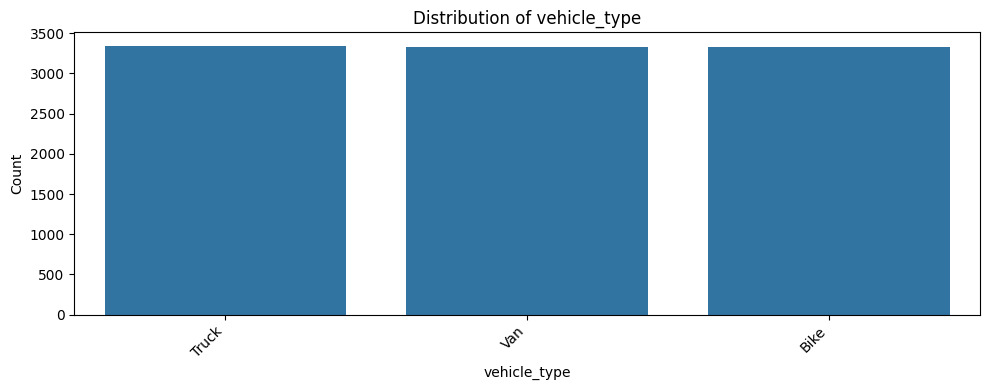


 ANALYSIS: delivery_mode | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 1

Top categories:


,Count,%
delivery_mode,,
Standard,10000,100.0



 No category < 1.0%
 STRONG IMBALANCE: 'Standard' = 100.0%


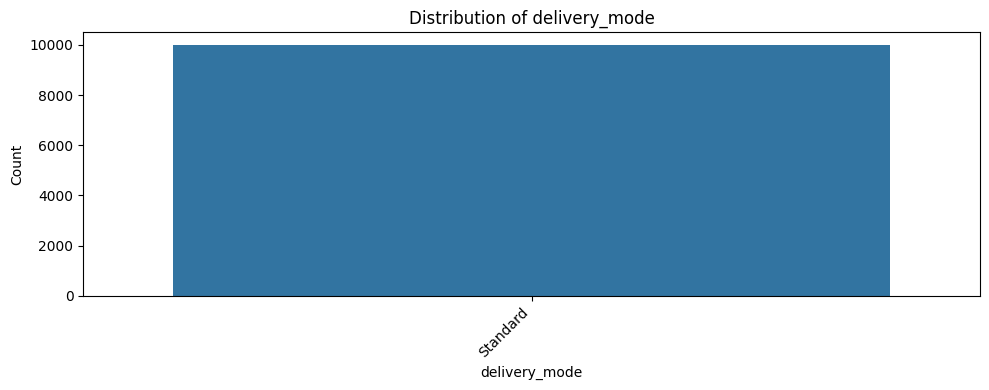


 ANALYSIS: weather_condition | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 4

Top categories:


,Count,%
weather_condition,,
Rainy,2546,25.46
Heavy Rain,2520,25.20
Harmattan,2468,24.68
Sunny,2466,24.66



 No category < 1.0%


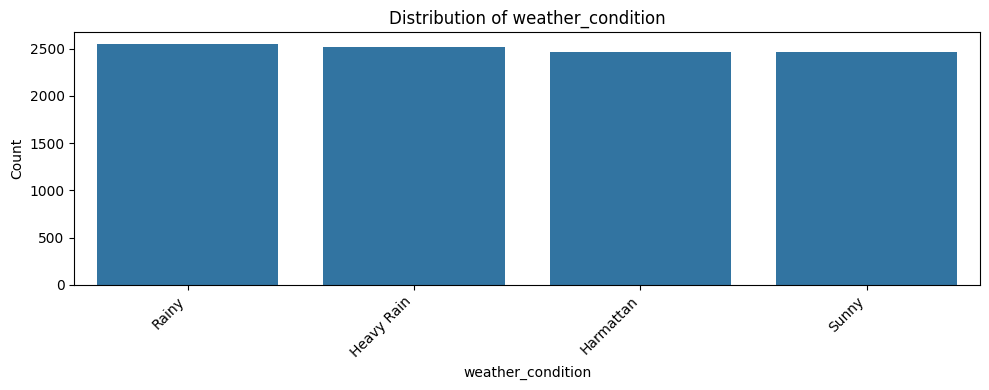


 ANALYSIS: traffic_level | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 4

Top categories:


,Count,%
traffic_level,,
Heavy,3368,33.68
Low,3285,32.85
Moderate,3255,32.55
Hevy,92,0.92



 1 categor(y/ies) < 1.0% -> Risk of overfitting. Consider grouping into 'Other'.
['Hevy']


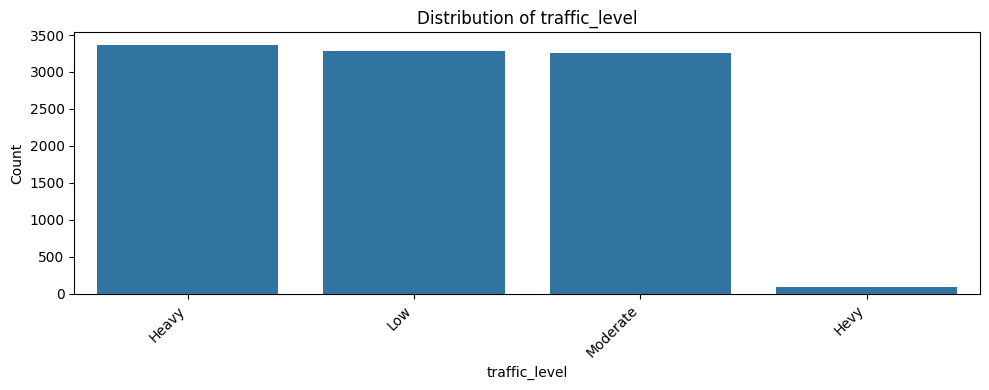


 ANALYSIS: road_condition | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 3

Top categories:


,Count,%
road_condition,,
Fair,3408,34.08
Good,3310,33.10
Bad,3282,32.82



 No category < 1.0%


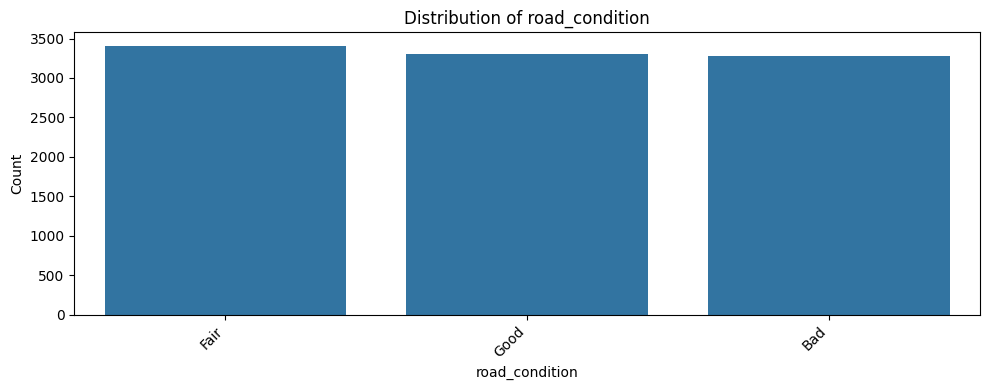


 ANALYSIS: driver_id | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 500

Top categories:


,Count,%
driver_id,,
DRV0491,33,0.33
DRV0054,33,0.33
DRV0092,31,0.31
DRV0149,31,0.31
DRV0005,30,0.30
DRV0129,30,0.30
DRV0030,29,0.29
DRV0136,29,0.29
DRV0155,29,0.29



 500 categor(y/ies) < 1.0% -> Risk of overfitting. Consider grouping into 'Other'.
['DRV0491', 'DRV0054', 'DRV0092', 'DRV0149', 'DRV0005', 'DRV0129', 'DRV0030', 'DRV0136', 'DRV0155', 'DRV0495', 'DRV0218', 'DRV0428', 'DRV0169', 'DRV0187', 'DRV0056', 'DRV0041', 'DRV0384', 'DRV0086', 'DRV0095', 'DRV0480', 'DRV0192', 'DRV0233', 'DRV0434', 'DRV0352', 'DRV0053', 'DRV0111', 'DRV0168', 'DRV0280', 'DRV0333', 'DRV0394', 'DRV0241', 'DRV0122', 'DRV0048', 'DRV0153', 'DRV0397', 'DRV0447', 'DRV0182', 'DRV0017', 'DRV0436', 'DRV0206', 'DRV0013', 'DRV0156', 'DRV0250', 'DRV0292', 'DRV0405', 'DRV0209', 'DRV0080', 'DRV0194', 'DRV0393', 'DRV0418', 'DRV0467', 'DRV0236', 'DRV0097', 'DRV0051', 'DRV0438', 'DRV0492', 'DRV0137', 'DRV0089', 'DRV0198', 'DRV0412', 'DRV0157', 'DRV0338', 'DRV0245', 'DRV0298', 'DRV0047', 'DRV0045', 'DRV0261', 'DRV0188', 'DRV0154', 'DRV0407', 'DRV0390', 'DRV0310', 'DRV0127', 'DRV0070', 'DRV0316', 'DRV0422', 'DRV0368', 'DRV0373', 'DRV0496', 'DRV0311', 'DRV0286', 'DRV0425', 'DRV0185', 'D

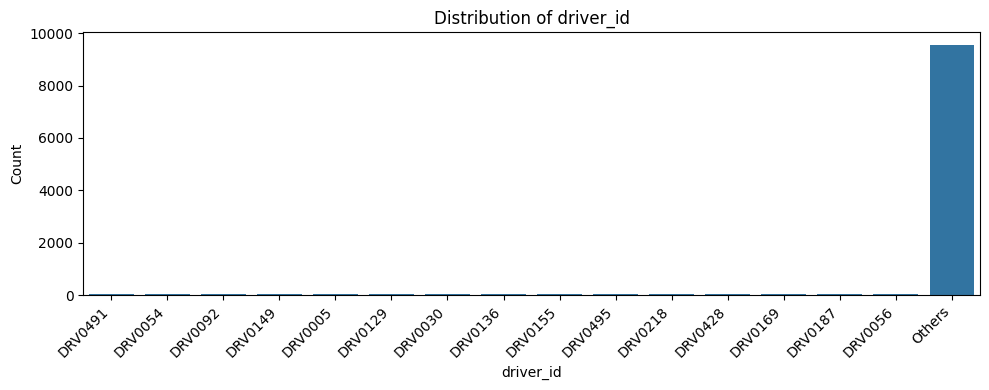


 ANALYSIS: customer_available | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 2

Top categories:


,Count,%
customer_available,,
No,5044,50.44
Yes,4956,49.56



 No category < 1.0%


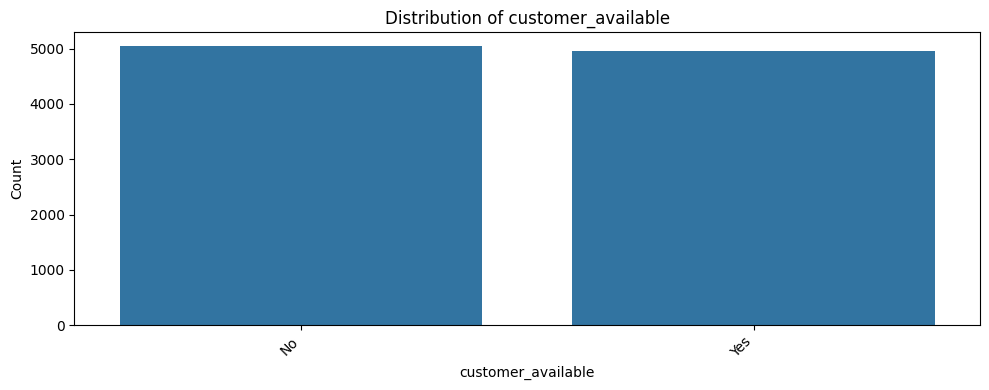


 ANALYSIS: address_verified | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 2

Top categories:


,Count,%
address_verified,,
No,5014,50.14
Yes,4986,49.86



 No category < 1.0%


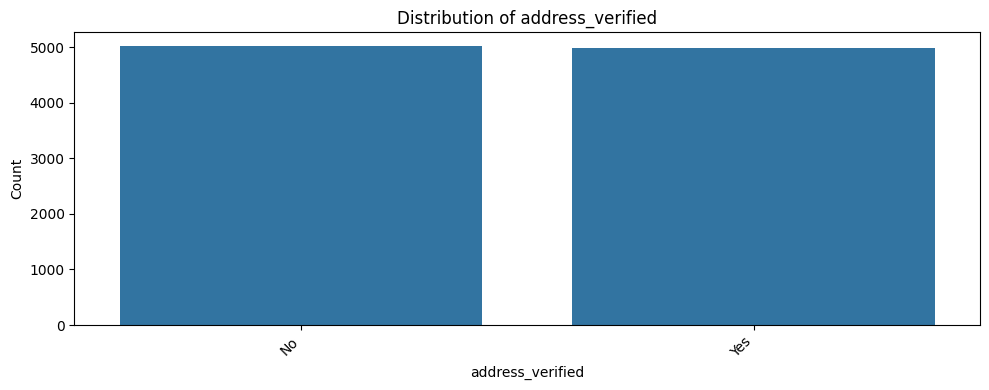


 ANALYSIS: payment_method | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 3

Top categories:


,Count,%
payment_method,,
Transfer,3363,33.63
Cash on Delivery,3342,33.42
Card,3295,32.95



 No category < 1.0%


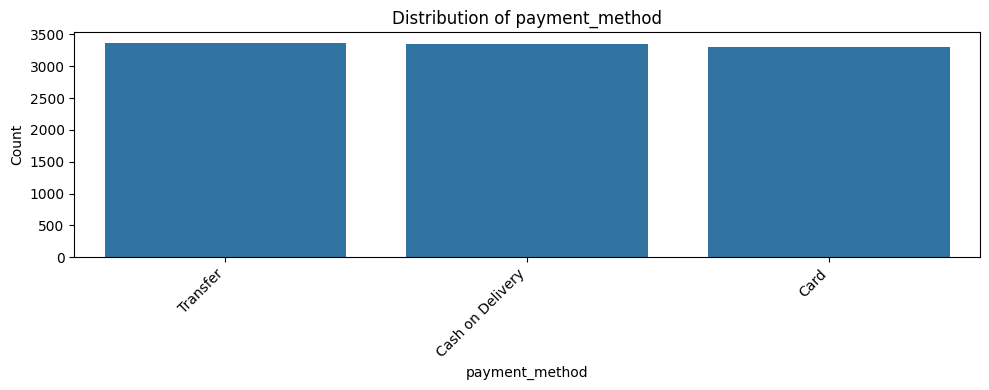


 ANALYSIS: fuel_level | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 3

Top categories:


,Count,%
fuel_level,,
Medium,3398,33.98
Low,3342,33.42
High,3260,32.60



 No category < 1.0%


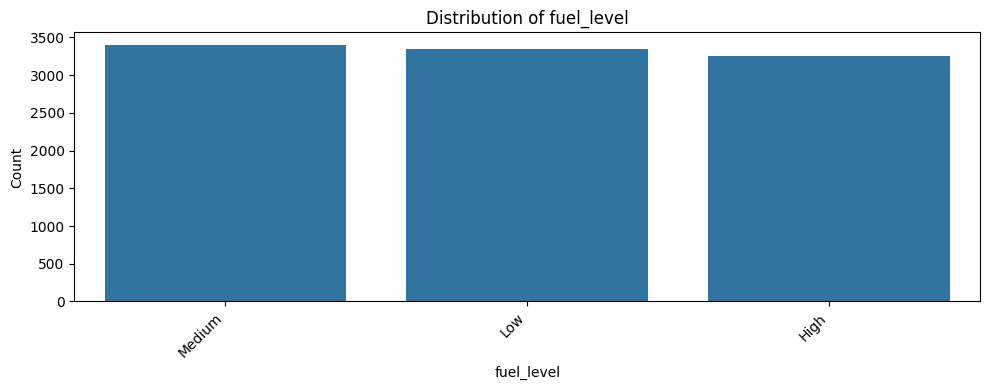


 ANALYSIS: vehicle_breakdown | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 2

Top categories:


,Count,%
vehicle_breakdown,,
Yes,5163,51.63
No,4837,48.37



 No category < 1.0%


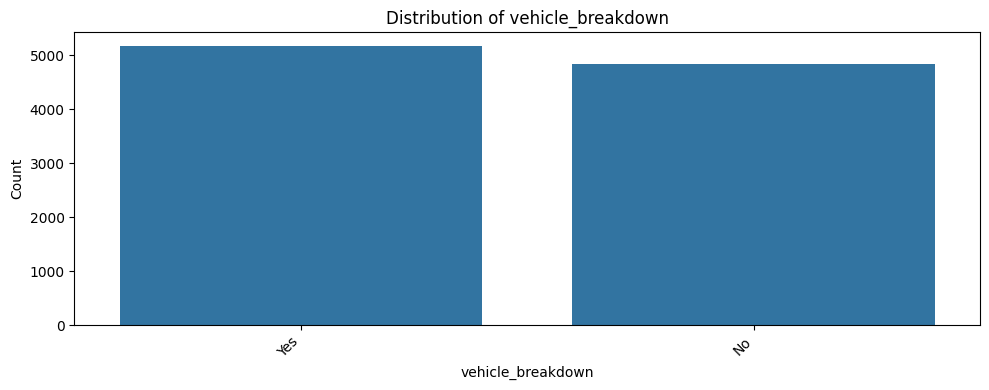


 ANALYSIS: holiday | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 2

Top categories:


,Count,%
holiday,,
No,5031,50.31
Yes,4969,49.69



 No category < 1.0%


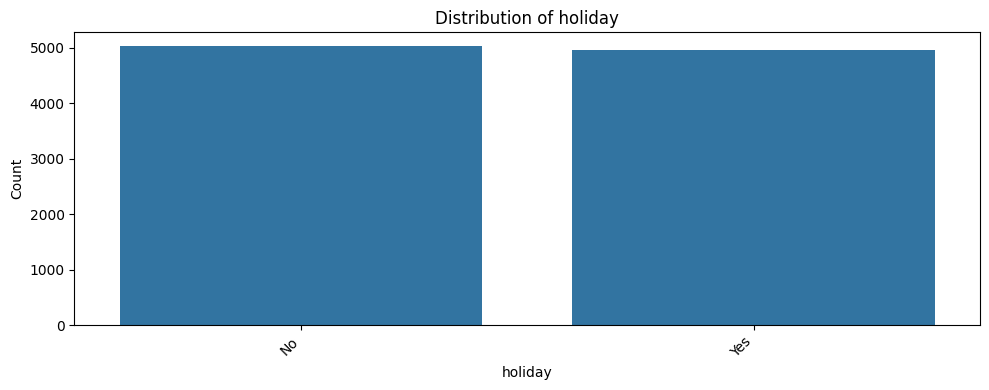

 Column faillaire_reason not found, skipping.

 ANALYSIS: delivery_status | Type: str
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 2

Top categories:


,Count,%
delivery_status,,
Delivered,5857,58.57
Failed,4143,41.43



 No category < 1.0%


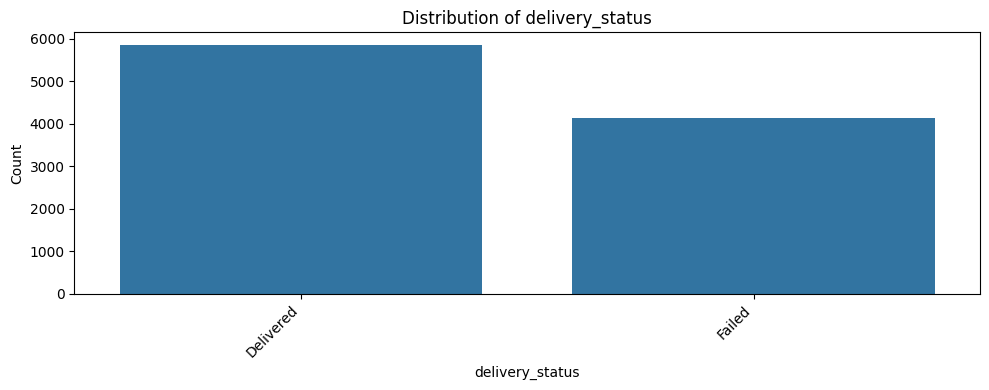


 ANALYSIS: delivery_failure | Type: int64
Total rows: 10,000 | NaN count: 0 | 0.00%
Number of unique categories: 2

Top categories:


,Count,%
delivery_failure,,
0,5857,58.57
1,4143,41.43



 No category < 1.0%


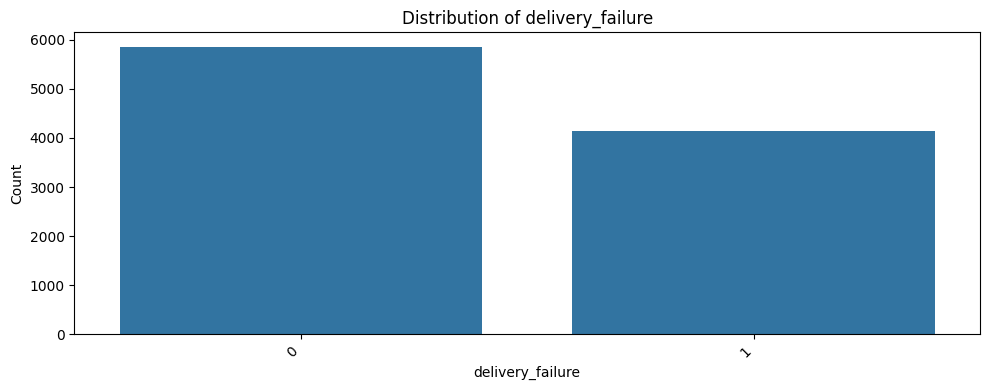


 GLOBAL SUMMARY TABLE


,n_unique,%_NaN,Mode,%_Mode
delivery_partner,4.0,0.0,GIG Logistics,25.80
order_date,1.0,0.0,2025-01-01,100.00
delivery_date,1.0,0.0,2025-01-02,100.00
state,6.0,0.0,Kano,17.74
city,10.0,0.0,Kano,17.60
package_type,3.0,0.0,Food,34.30
vehicle_type,3.0,0.0,Truck,33.43
delivery_mode,1.0,0.0,Standard,100.00
weather_condition,4.0,0.0,Rainy,25.46
traffic_level,4.0,0.0,Heavy,33.68


,n_unique,%_NaN,Mode,%_Mode
delivery_partner,4.0,0.0,GIG Logistics,25.80
order_date,1.0,0.0,2025-01-01,100.00
delivery_date,1.0,0.0,2025-01-02,100.00
state,6.0,0.0,Kano,17.74
city,10.0,0.0,Kano,17.60
package_type,3.0,0.0,Food,34.30
vehicle_type,3.0,0.0,Truck,33.43
delivery_mode,1.0,0.0,Standard,100.00
weather_condition,4.0,0.0,Rainy,25.46
traffic_level,4.0,0.0,Heavy,33.68


In [24]:
def analyze_categorical(df, columns=None, top_n=15, rare_threshold=0.01):
    # 1. Auto-select categorical 
    if columns is None:
        columns = df.select_dtypes(include=['string']).columns.tolist()

    if not columns:
        print("No categorical columns found.")
        return

    global_summary = pd.DataFrame()

    for col in columns:
        if col not in df.columns:
            print(f" Column {col} not found, skipping.")
            continue

        print(f"\n{'='*50}")
        print(f" ANALYSIS: {col} | Type: {df[col].dtype}")
        print(f"{'='*50}")

        # 2. Basic stats
        n_unique = df[col].nunique(dropna=True)
        n_nan = df[col].isna().sum()
        pct_nan = n_nan / len(df) * 100

        print(f"Total rows: {len(df):,} | NaN count: {n_nan:,} | {pct_nan:.2f}%")
        print(f"Number of unique categories: {n_unique}")

        # 3. Frequency table
        vc = df[col].value_counts(dropna=False, normalize=True) * 100
        vc_abs = df[col].value_counts(dropna=False)
        table = pd.DataFrame({'Count': vc_abs, '%': vc.round(2)})
        print("\nTop categories:")
        display(table.head(top_n))

        # 4. Detect rare categories
        rare = table[table['%'] < rare_threshold * 100]
        if not rare.empty:
            print(f"\n {len(rare)} categor(y/ies) < {rare_threshold*100}% -> Risk of overfitting. Consider grouping into 'Other'.")
            print(rare.index.tolist())
        else:
            print(f"\n No category < {rare_threshold*100}%")

        # 5. Detect strong imbalance
        if table['%'].iloc[0] > 90:
            print(f" STRONG IMBALANCE: '{table.index[0]}' = {table['%'].iloc[0]:.1f}%")

        # 6. Plot
        plt.figure(figsize=(10, 4))
        plot_data = df[col].value_counts(dropna=False).head(top_n)
        if n_unique > top_n:
            plot_data['Others'] = df[col].value_counts(dropna=False).iloc[top_n:].sum()

        sns.barplot(x=plot_data.index.astype(str), y=plot_data.values)
        plt.title(f'Distribution of {col}')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        # 7. Summary for global table
        global_summary.loc[col, 'n_unique'] = n_unique
        global_summary.loc[col, '%_NaN'] = pct_nan

        if len(table) > 0: 
           global_summary.loc[col, 'Mode'] = str(table.index[0]) 
           global_summary.loc[col, '%_Mode'] = float(table['%'].iloc[0]) 
        else:
            global_summary.loc[col, 'Mode'] = 'NaN'
            global_summary.loc[col, '%_Mode'] = np.nan 

    print(f"\n{'='*50}")
    print(" GLOBAL SUMMARY TABLE")
    print(f"{'='*50}")
    display(global_summary.round(2))

    return global_summary

categorical_cols_all = [
    'delivery_partner', 
    'order_date',        
    'delivery_date',     
    'state',             
    'city',              
    'package_type',      
    'vehicle_type',      
    'delivery_mode',     
    'weather_condition', 
    'traffic_level',     
    'road_condition',    
    'driver_id',         
    'customer_available',
    'address_verified',  
    'payment_method',    
    'fuel_level',        
    'vehicle_breakdown', 
    'holiday',
    'faillaire_reason',               
    'delivery_status',   
    'delivery_failure'  ] 
analyze_categorical(df,categorical_cols_all)